# Machine Learning 
## Lab Session 2 -  Data Preprocessing
## Topic: Data Understanding, Cleaning, normalization, slicing and Feature Engineering
## Dataset: Titanic (Structured Data)

## 1 PROBLEM STATEMENT

"""
Problematic Statement:
Predict whether a passenger survived the Titanic disaster .

Task Type:
Binary Classification

Objective:
Learn a function f(x) that maps passenger features -> survival label.
"""

Step 1 — Data Understanding (EDA)
Step 2 — Data Cleaning
Step 3 — Data Splitting
Step 4 — Data Transformation
Step 5 — Visualization

## 2 IMPORT LIBRARIES
**matplotlib**
**pandas**

In [1]:
# Importlibraries
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np


## 3 LOAD DATA
- <u>Question:</u> Use a "pandas" methode to load the csv file, in order to store the data in a data frame?

In [2]:
# Load data
df = pd.read_csv('train.csv')
display(df.head())


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4 DATASET DESCRIPTION
"""
Attributes Description:
- Survived: Target (0 = No, 1 = Yes)
- Pclass: Ticket class (1,2,3)
- Sex: Gender (male/female)
- Age: Age in years
- SibSp: # siblings/spouses aboard
- Parch: # parents/children aboard
- Fare: Ticket fare/Price
- Embarked: Port of embarkation

- <u>Question:</u> Use a slicing technique to input features and Target?  
X: All except 'Survived'  
y: Survived


In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']
print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (891, 11)
y shape: (891,)


## DATA UNDERSTANDING

<u>Questions:</u>  
- get a quick look at your data structure and values by displaying the first rows of your DataFrame?  
- Prints a summary of the DataFrame?  
- Generates statistical summaries of the DataFrame?

In [ ]:
display(df.head())
print('\n--- Info ---')
display(df.info())
print('\n--- Describe ---')
display(df.describe())


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None


--- Describe ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## DATA UNDERSTANDING

<u>Questions:</u> display the data type of each column in your DataFrame?

In [ ]:
display(df.dtypes)


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Questions:
1. Which features are numerical?
2. Which features are categorical?
3. Are there missing values?

1. numerical: passengerId, Survived, SibSp, Parch, Fare, Age
2. categorical: Sex, Pclass, embarked,cabin
3. yes there is some missing values

## Data Preprocessing: DATA Cleaning + Transformation (Normalization / Encoding) + Dimesion Reduction 

### Pclass Attribute

Inspect Pclass Values

In [ ]:
print("Sorted unique values:")
print(sorted(df['Pclass'].unique()))

Sorted unique values:
[np.int64(1), np.int64(2), np.int64(3)]


Frequency of Each Class  
- <u>Questions:</u>  
Count how many passengers belong to each class?  
Visualize distribution of passenger classes using matplotlib?

In [ ]:
pclass_counts = df['Pclass'].value_counts()
print(pclass_counts)


Pclass
3    491
1    216
2    184
Name: count, dtype: int64


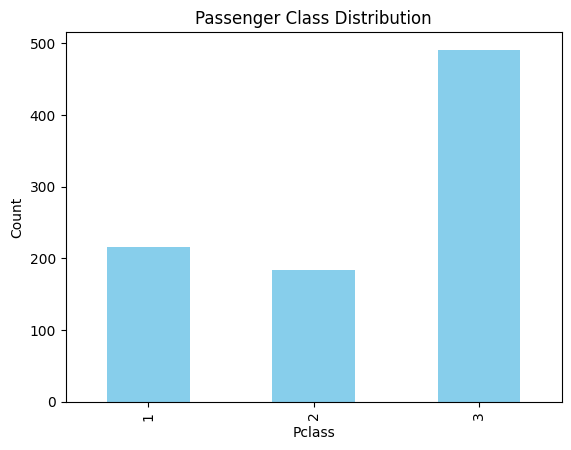

In [ ]:
pclass_counts.sort_index().plot(kind='bar', color='skyblue')
plt.title('Passenger Class Distribution')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.show()


- <u>Question:</u> What do you observe at this level?

We observe that the most passenger are from class 3.

### Name Attribute

Inspect the Name Attribute  
- <u>Question:</u> Display sample names?

In [ ]:
print(df['Name'].head(10))


0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: object


What observations can you make at this stage regarding the dataset?

the dataset need some cleaning, it doesnt seems to be ready for training.

In [ ]:
print('Unique names:', df['Name'].nunique())
print('Total rows:', len(df))


Unique names: 891
Total rows: 891


What do you notice?

The name has no meaning to add it into the trainning data (but we can extarct sex from it, but we already have sex column, so the column is'nt needed).

In [ ]:
name_lengths = df['Name'].apply(len)
print(name_lengths.describe())


count    891.000000
mean      26.965208
std        9.281607
min       12.000000
25%       20.000000
50%       25.000000
75%       30.000000
max       82.000000
Name: Name, dtype: float64


- <u>Question:</u> Plot the distribution of name length?

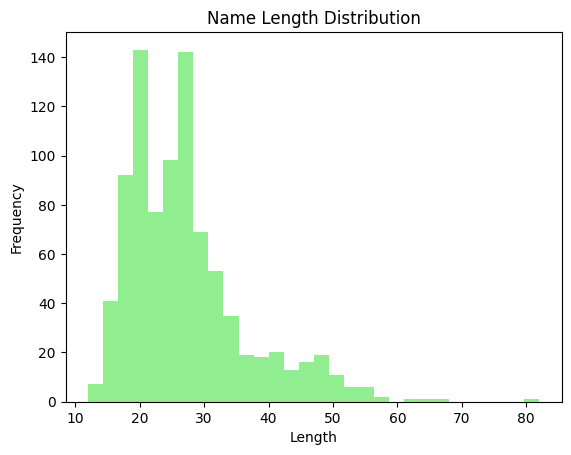

In [ ]:
name_lengths.plot(kind='hist', bins=30, color='lightgreen')
plt.title('Name Length Distribution')
plt.xlabel('Length')
plt.show()


In [ ]:
sorted_names = df['Name'].iloc[name_lengths.sort_values(ascending=False).index]
print(sorted_names.head(10))


307    Penasco y Castellana, Mrs. Victor de Satode (M...
427    Phillips, Miss. Kate Florence ("Mrs Kate Louis...
556    Duff Gordon, Lady. (Lucille Christiana Sutherl...
670    Brown, Mrs. Thomas William Solomon (Elizabeth ...
25     Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...
610    Andersson, Mrs. Anders Johan (Alfrida Konstant...
759    Rothes, the Countess. of (Lucy Noel Martha Dye...
41     Turpin, Mrs. William John Robert (Dorothy Ann ...
319    Spedden, Mrs. Frederic Oakley (Margaretta Corn...
18     Vander Planke, Mrs. Julius (Emelia Maria Vande...
Name: Name, dtype: object


In [ ]:
titles = df['Name'].apply(lambda x: re.search(' ([A-Za-z]+)\.', x).group(1) if pd.notnull(x) and re.search(' ([A-Za-z]+)\.', x) else None)
print(titles.unique())


['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer']


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\YOGA\AppData\Local\Temp\ipykernel_20960\3277429518.py:2: SyntaxWarning: invalid escape sequence '\.'
  titles = df['Name'].apply(lambda x: re.search(' ([A-Za-z]+)\.', x).group(1) if pd.notnull(x) and re.search(' ([A-Za-z]+)\.', x) else None)
C:\Users\YOGA\AppData\Local\Temp\ipykernel_20960\3277429518.py:2: SyntaxWarning: invalid escape sequence '\.'
  titles = df['Name'].apply(lambda x: re.search(' ([A-Za-z]+)\.', x).group(1) if pd.notnull(x) and re.search(' ([A-Za-z]+)\.', x) else None)


In [ ]:
print(titles.value_counts())


Name
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


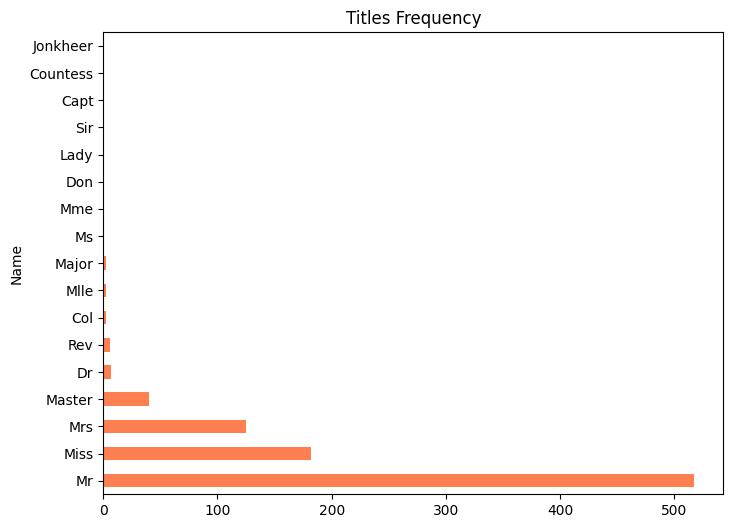

In [ ]:
titles.value_counts().plot(kind='barh', color='coral', figsize=(8,6))
plt.title('Titles Frequency')
plt.show()


In [ ]:
print(titles.value_counts().head(10))


Name
Mr        517
Miss      182
Mrs       125
Master     40
Dr          7
Rev         6
Col         2
Mlle        2
Major       2
Ms          1
Name: count, dtype: int64


In [ ]:
def remove_titles(name):
    return re.sub(' ([A-Za-z]+)\.', '', name)
# Apply the transformation
df['Name_clean'] = df['Name'].apply(remove_titles)
# Display comparison
print(df[['Name', 'Name_clean']].head(10))


<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
C:\Users\YOGA\AppData\Local\Temp\ipykernel_20960\3389981584.py:3: SyntaxWarning: invalid escape sequence '\.'
  return re.sub(' ([A-Za-z]+)\.', '', name)


                                                Name  \
0                            Braund, Mr. Owen Harris   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2                             Heikkinen, Miss. Laina   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4                           Allen, Mr. William Henry   
5                                   Moran, Mr. James   
6                            McCarthy, Mr. Timothy J   
7                     Palsson, Master. Gosta Leonard   
8  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)   
9                Nasser, Mrs. Nicholas (Adele Achem)   

                                       Name_clean  
0                             Braund, Owen Harris  
1  Cumings, John Bradley (Florence Briggs Thayer)  
2                                Heikkinen, Laina  
3         Futrelle, Jacques Heath (Lily May Peel)  
4                            Allen, William Henry  
5                                    Moran, James  
6                  

In [19]:
# Before cleaning
df['Name_length'] = df['Name'].apply(len)
# After cleaning
df['Name_clean_length'] = df['Name_clean'].apply(len)
# print statistical summaries
print(df[['Name_length', 'Name_clean_length']].describe())


       Name_length  Name_clean_length
count   891.000000         891.000000
mean     26.965208          22.191919
std       9.281607           9.065689
min      12.000000           8.000000
25%      20.000000          15.000000
50%      25.000000          21.000000
75%      30.000000          26.000000
max      82.000000          77.000000

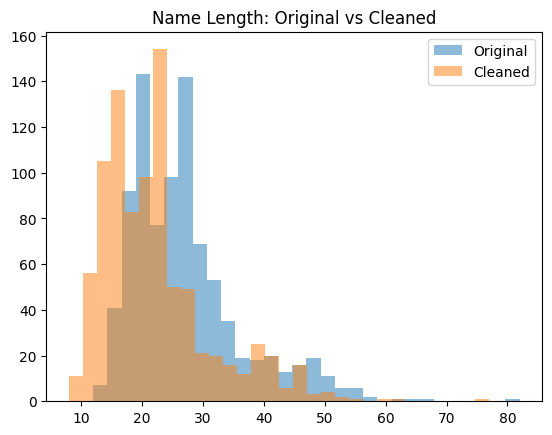

In [20]:
# uses Matplotlib to compare the distribution
plt.hist(df['Name_length'], alpha=0.5, label='Original', bins=30)
plt.hist(df['Name_clean_length'], alpha=0.5, label='Cleaned', bins=30)
plt.legend()
plt.title('Name Length: Original vs Cleaned')
plt.show()


At this stage, we have explored several text cleaning transformations. However, for this task, it is preferable to drop the Name attribute, as it behaves like an identifier: each instance has a unique value and does not provide useful information for prediction.

In [21]:
# Drop the name column
df = df.drop(['Name', 'Name_clean', 'Name_length', 'Name_clean_length'], axis=1)


In [22]:
# Display the names of all columns
print(df.columns)


Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


### Question: Remove all extra columns and keep only the ones we selected.

##### Sex Attribute

### Question: Display :
             -- unique values for the Sex attribute.
             -- First 10 raw values for the Sex column
             -- Statistics related to each class (rates, graph)
             -- What do you remark ?

In [23]:
# unique values for the Sex attribute
print(df['Sex'].unique())


['male' 'female']


In [24]:
# First 10 raw values for the Sex column
print(df['Sex'].head(10))


0      male
1    female
2    female
3    female
4      male
5      male
6      male
7      male
8    female
9    female
Name: Sex, dtype: object


In [25]:
# Statistics related to each class (rates, graph)
sex_rates = df['Sex'].value_counts(normalize=True)
print('Rates:\n', sex_rates)


Rates:
 Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64


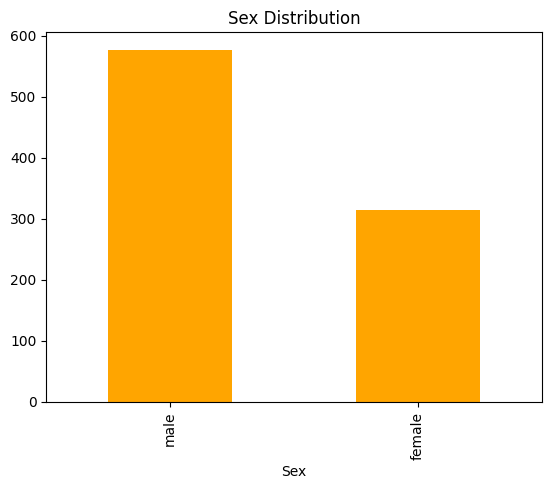

In [26]:
df['Sex'].value_counts().plot(kind='bar', color='orange')
plt.title('Sex Distribution')
plt.show()


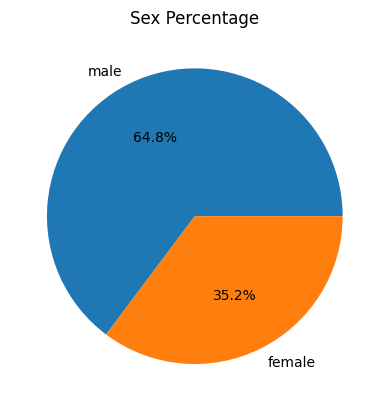

In [27]:
# Empty or pie chart
df['Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Sex Percentage')
plt.ylabel('')
plt.show()


In [28]:
# compute survival rates by gender.
print(df.groupby('Sex')['Survived'].mean())


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


#### Question: Interpretation?

##### One-hot encoding for Sex Attribute

In [29]:
# Encode: male = 1, female = 0
df['Sex_encoded'] = df['Sex'].map({'male': 1, 'female': 0})


In [30]:
# display of head values: gender attribute
print(df[['Sex', 'Sex_encoded']].head(10))


      Sex  Sex_encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1
5    male            1
6    male            1
7    male            1
8  female            0
9  female            0


### Question: Aplly encoding using the following rule: male: 1 , female : 0.

### Age Attribute

#### Question: Display current existing columns in your dataset

In [31]:
# Display current existing columns
print(df.columns)


Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Sex_encoded'],
      dtype='object')


#### Question: Display head values for the Age attribute (first 10 values)

In [32]:
# Display head values for the Age attribute (first 10 values)
print(df['Age'].head(10))


0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5     NaN
6    54.0
7     2.0
8    27.0
9    14.0
Name: Age, dtype: float64


#### Question : What do you remark?

There are some missing values from age column.

In [33]:
#check column data type
print(df['Age'].dtype)


float64


In [34]:
#count missing/empty values
print(df['Age'].isna().sum())


177


In [35]:
#print the rate of missing values
print(df['Age'].isna().mean())


0.19865319865319866


In [36]:
# Save where Age is missing
missing_mask = df['Age'].isna()


**Decision**: Why NOT drop rows?

it has a meaning in our model(most children and elderly people survuived)

##### Median Imputation

Missing values in the Age attribute can be filled using the median of the entire column. This approach is simple and robust to outliers, as the median is not affected by extreme values

In [37]:
#age attribute: median imputation
df_median = df.copy()
df_median['Age'] = df_median['Age'].fillna(df_median['Age'].median())


In [38]:
#verification
print(df_median.loc[missing_mask, 'Age'].head())


5     28.0
17    28.0
19    28.0
26    28.0
28    28.0
Name: Age, dtype: float64


Group-Based Imputation

A more advanced approach consists of imputing missing Age values based on groups defined by relevant features such as Sex and Pclass. This method replaces missing values with the median Age of similar passengers, leading to more accurate and context-aware estimations.

In [39]:
df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))


In [40]:
#verification
print(df.loc[missing_mask, 'Age'].head())


5     25.0
17    30.0
19    21.5
26    25.0
28    21.5
Name: Age, dtype: float64


#### Question: Plot the function f(Age), where f denotes the frequency (number of individuals) corresponding to each age value.

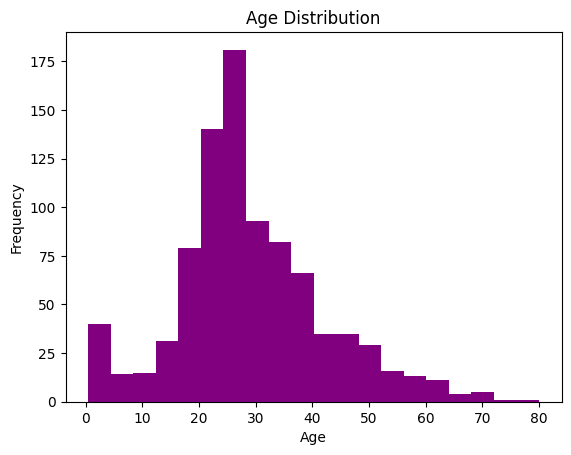

In [41]:
df['Age'].plot(kind='hist', bins=20, color='purple')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()


#### Question: what you have remarked on this ghraph?

Most people are in the adult age gap

Categorisation of people based on the age value. 
Classes are the following:
                 -- young: age < 18
                 -- adult: 18 ≤ age < 60
                 -- older: age ≥ 60

In [42]:
# Create AgeGroup
def categorize_age(age):
    if age < 18: return 'young'
    elif age < 60: return 'adult'
    else: return 'older'
df['AgeGroup'] = df['Age'].apply(categorize_age)
# Display first rows
print(df[['Age', 'AgeGroup']].head(10))


    Age AgeGroup
0  22.0    adult
1  38.0    adult
2  26.0    adult
3  35.0    adult
4  35.0    adult
5  25.0    adult
6  54.0    adult
7   2.0    young
8  27.0    adult
9  14.0    young


In [43]:
# Encode age groups
df['AgeGroup_encoded'] = df['AgeGroup'].map({'young': 1, 'adult': 2, 'older': 3})


In [44]:
# Display result
print(df[['AgeGroup', 'AgeGroup_encoded']].head())


  AgeGroup  AgeGroup_encoded
0    adult                 2
1    adult                 2
2    adult                 2
3    adult                 2
4    adult                 2


Visualize the 3 classes: Statistics

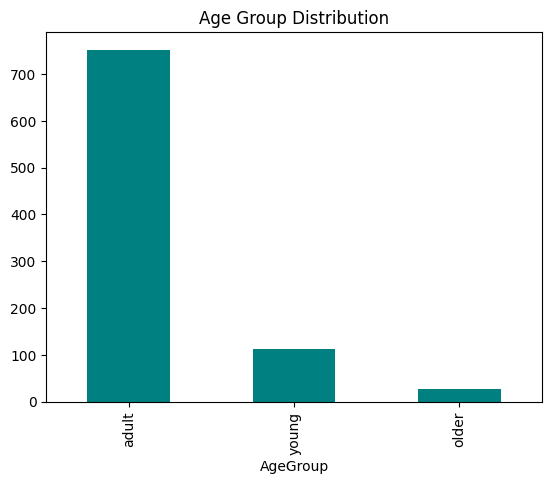

In [45]:
df['AgeGroup'].value_counts().plot(kind='bar', color='teal')
plt.title('Age Group Distribution')
plt.show()


<u>Questions:</u>  
- Is there a class imbalance in the Age feature distribution?  
- What is the impact of this imbalance?

1. most of them are in adult age gap
2. as we now that most of the adult didnt survived, so this could impact ouyr model

#### Question: Make: 
                -- Encode:     'Child' :1,'Teen' :2, 'YoungAdult' :3, 'Adult' :4, 'Senior' :5 (create new column)
                -- Display the first 10 values of the age column after transformation
                -- Dispaly the distribution of age groups
                -- what you not at this stage

What is next?

0    3
1    4
2    3
3    3
4    3
5    3
6    4
7    1
8    3
9    2
Name: Age_group_encoded, dtype: int64
Age_group_encoded
3    489
4    216
2     95
1     69
5     22
Name: count, dtype: int64


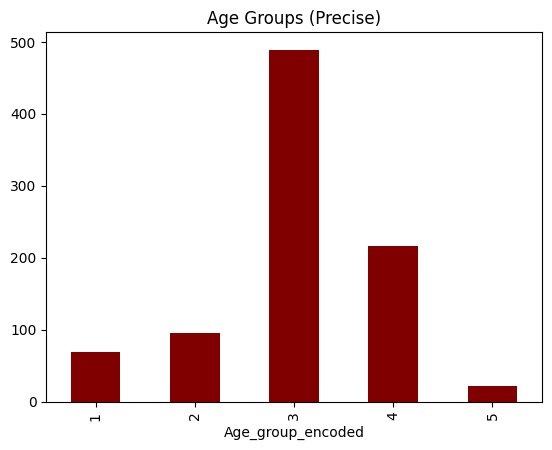

Columns: Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Sex_encoded', 'AgeGroup',
       'AgeGroup_encoded', 'Age_group_encoded'],
      dtype='object')


In [ ]:
def precise_age_encode(age):
    if age < 13: return 1
    elif age <= 19: return 2
    elif age <= 35: return 3
    elif age <= 60: return 4
    else: return 5
df['Age_group_encoded'] = df['Age'].apply(precise_age_encode)
print(df['Age_group_encoded'].head(10))
print(df['Age_group_encoded'].value_counts())
df['Age_group_encoded'].value_counts().sort_index().plot(kind='bar', color='maroon')
plt.title('Age Groups (Precise)')
plt.show()
print('Columns:', df.columns)


### SibSp Attribute

Question: -- display the data type of SibSp
          -- Check if there are any empty values

In [47]:
print(df['SibSp'].dtype)


int64


In [48]:
print('Empty values:', df['SibSp'].isna().sum())


Empty values: 0


#### Question: Write a Python script to visualize the function 
𝑓(𝑥=SibSp), where 𝑓(𝑥) represents the frequency (number of passengers) having a given number of siblings/spouses (SibSp). Choose a horizontal bar representation.

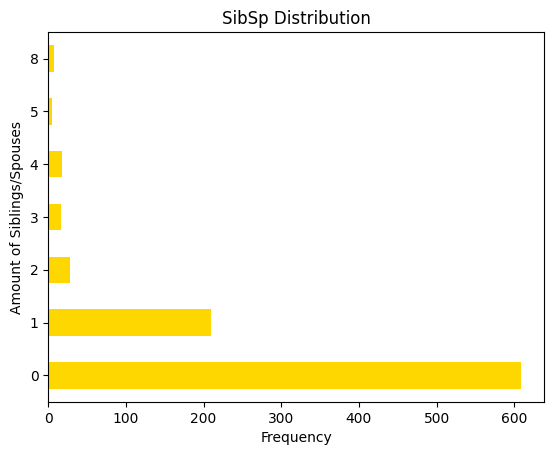

In [49]:
df['SibSp'].value_counts().sort_index().plot(kind='barh', color='gold')
plt.title('SibSp Distribution')
plt.xlabel('Frequency')
plt.ylabel('Amount of Siblings/Spouses')
plt.show()


Question: What do you observe? Can we group categories with small frequencies?

most people didnt travl with sibling, and yes we can categorize thgis coilumn

### Parch Attribute

#### Question: Similarily, display:
              -- data type of the Parch attribute
              -- verify if it exists empty values in you dataset
              -- display the rate of empty values (if existing)
              -- plot the graph f(x=Parch), f: number of passengers (barh representation)

In [50]:
print(df['Parch'].dtype)


int64


In [51]:
print('Empty values:', df['Parch'].isna().sum())


Empty values: 0


No missing values


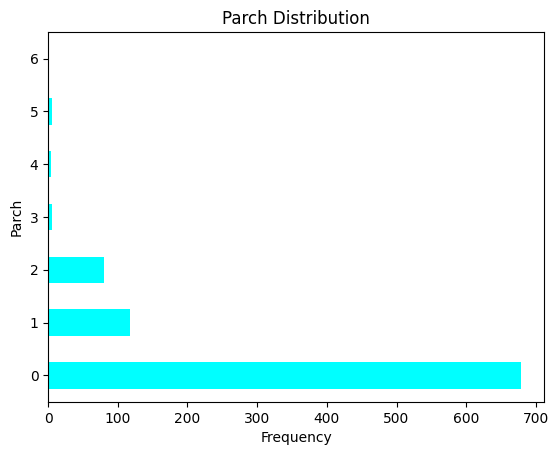

In [52]:
if df['Parch'].isna().sum() > 0: print('Rate:', df['Parch'].isna().mean())
else: print('No missing values')
df['Parch'].value_counts().sort_index().plot(kind='barh', color='cyan')
plt.title('Parch Distribution')
plt.xlabel('Frequency')
plt.show()


We can reduce the dimensionality of the input feature space by introducing a new attribute, FamilySize, defined as:
FamilySize = SibSp + Parch + 1 (1 : the passenger), which serves as a **data reduction** step

### FamilySize Attribute

In [53]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1


In [54]:
print(df.columns)


Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Sex_encoded', 'AgeGroup',
       'AgeGroup_encoded', 'Age_group_encoded', 'FamilySize'],
      dtype='object')


In [55]:
#display header values
print(df[['SibSp', 'Parch', 'FamilySize']].head(10))


   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1
5      0      0           1
6      0      0           1
7      3      1           5
8      0      2           3
9      1      0           2


#### Question: Similarily, display:
              -- plot the graph f(x=FamilySize), f: number of passengers (barh representation)

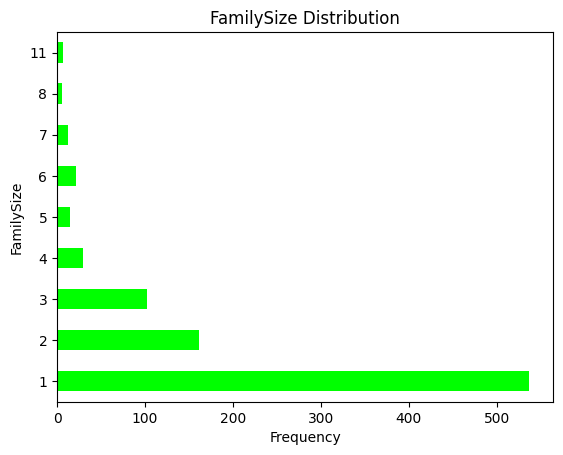

In [56]:
df['FamilySize'].value_counts().sort_index().plot(kind='barh', color='lime')
plt.title('FamilySize Distribution')
plt.xlabel('Frequency')
plt.show()


#### Question: What should we do at this stage? What do you suggest as a categorization based on family size?


i Suggest grouping FamilySize as: 1 (Alone), 2-3 (Small), >3 (Big)


#### Question: Encoding 
                       -- Apply the following mapping:
                       Familysize= 1 : Alone
                       Familysize= 2 or 3 : small
                       Familysize= >3 : big

                       --Display head values

In [58]:
def encode_family(fs):
    if fs == 1: return 1 # Alone
    elif fs <= 3: return 2 # Small
    else: return 3 # Big
df['FamilyGroup_encoded'] = df['FamilySize'].apply(encode_family)
print(df[['FamilySize', 'FamilyGroup_encoded']].head())


   FamilySize  FamilyGroup_encoded
0           2                    2
1           2                    2
2           1                    1
3           2                    2
4           1                    1


#### Question: Similarily, display:
              -- plot the graph f(x=FamilySize), f: number of passengers (barh representation). (After encoding)

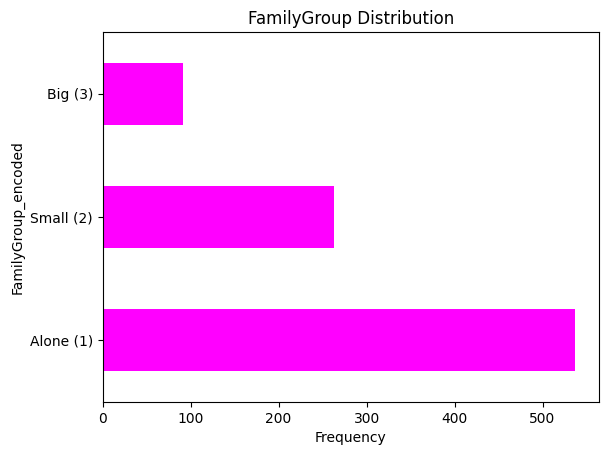

In [59]:
df['FamilyGroup_encoded'].value_counts().sort_index().plot(kind='barh', color='magenta')
plt.title('FamilyGroup Distribution')
plt.xlabel('Frequency')
plt.yticks([0, 1, 2], ['Alone (1)', 'Small (2)', 'Big (3)'])
plt.show()


What do you observe about the distribution of passengers based on family size before and after applying encoding?

it was confusing before

In [ ]:

print(df.columns)


Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Sex_encoded', 'AgeGroup',
       'AgeGroup_encoded', 'Age_group_encoded', 'FamilySize',
       'FamilyGroup_encoded'],
      dtype='object')


### Ticket Attribute

In [62]:
print(df['Ticket'].dtype)


object


In [63]:
print(df['Ticket'].head())


0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
Name: Ticket, dtype: object


In [64]:
has_letter = df['Ticket'].str.contains('[A-Za-z]', na=False)
print('Contains letter:', has_letter.sum())
print('Rate:', has_letter.mean())


Contains letter: 230
Rate: 0.25813692480359146


<u>Question:</u> Comment and add an intepretation of this rate?

i dont think that the ticket could have an influence on the model

In [65]:
print(df['Ticket'].nunique())


681


In [66]:
print('Rate unique:', df['Ticket'].nunique() / len(df))


Rate unique: 0.7643097643097643


#### Question: What is your interpretation of the provided result? what action can we do?

this means that we can drop this column

In [67]:
print(df.columns)


Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Sex_encoded', 'AgeGroup',
       'AgeGroup_encoded', 'Age_group_encoded', 'FamilySize',
       'FamilyGroup_encoded'],
      dtype='object')


### Fare Attribute

#### Question: Similarily, display:
              -- data type pf the Fare attribute
              -- verify if it exists empty values in you dataset
              -- display the rate of empty values (if existing)
              -- plot the graph f(x=Fare), f: number of passengers (line representation)

In [68]:
print(df['Fare'].dtype)


float64


In [69]:
print('Empty values:', df['Fare'].isna().sum())


Empty values: 0


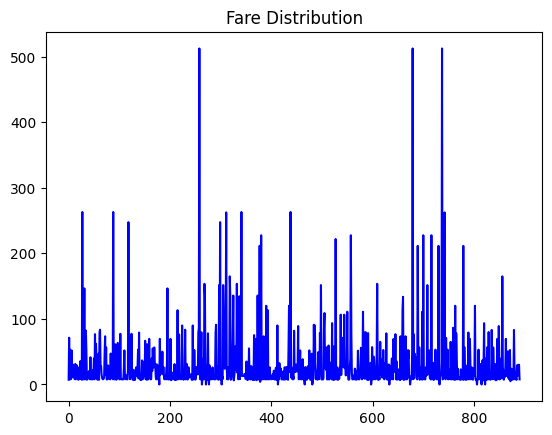

In [70]:
df['Fare'].plot(kind='line', color='blue')
plt.title('Fare Distribution')
plt.show()


Max/min Normalization

In [71]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['Fare_minmax'] = scaler.fit_transform(df[['Fare']])


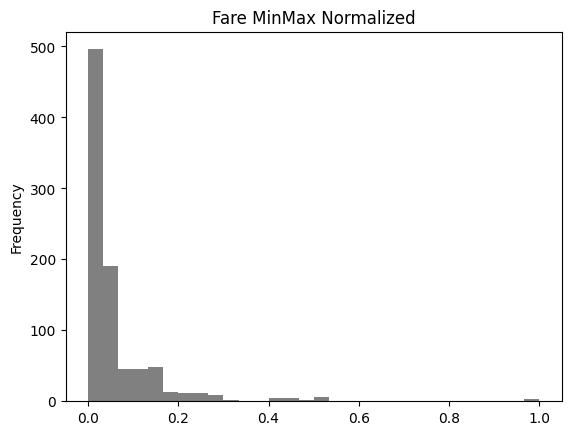

In [72]:
df['Fare_minmax'].plot(kind='hist', bins=30, color='grey')
plt.title('Fare MinMax Normalized')
plt.show()


In [73]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
df['Fare_zscore'] = std.fit_transform(df[['Fare']])


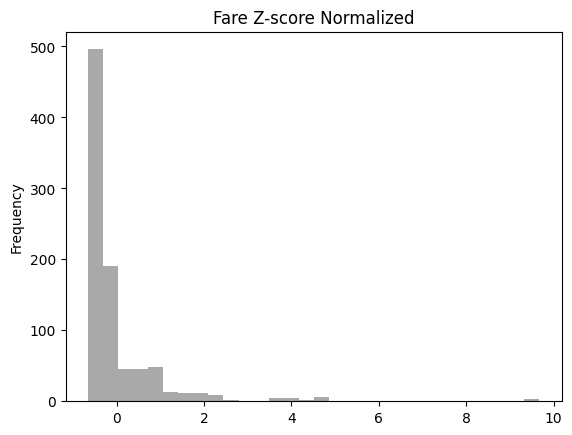

In [74]:
df['Fare_zscore'].plot(kind='hist', bins=30, color='darkgrey')
plt.title('Fare Z-score Normalized')
plt.show()


What observations can you make? Which normalization method is most appropriate for our dataset, or do both methods have similar effects?

### Cabin Attribute

#### Question: Similarily, display:
              -- data type pf the Parch attribute
              -- verify if there are empty values in you dataset
              -- display the rate of empty values (if existing)
              -- plot the graph f(x=Cabin), f: number of passengers (barh representation)

In [75]:
print(df['Cabin'].dtype)


object


Empty values: 687
Rate: 0.7710437710437711


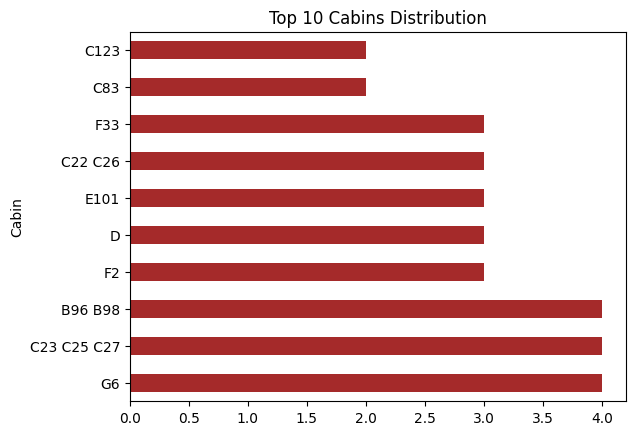

In [76]:
print('Empty values:', df['Cabin'].isna().sum())
print('Rate:', df['Cabin'].isna().mean())
df['Cabin'].value_counts().head(10).plot(kind='barh', color='brown')
plt.title('Top 10 Cabins Distribution')
plt.show()


#### Question: Remove the Cabin column from your dataset (Data cleaning) Verify that this feature was removed from your dataset.

In [77]:
df = df.drop('Cabin', axis=1)


In [78]:
print(df.columns)


Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked', 'Sex_encoded', 'AgeGroup',
       'AgeGroup_encoded', 'Age_group_encoded', 'FamilySize',
       'FamilyGroup_encoded', 'Fare_minmax', 'Fare_zscore'],
      dtype='object')


### Embarked Attribute

#### Question: Similarily, display:
              -- data type pf the Parch attribute
              -- verify if it exists empty values in you dataset
              -- display the rate of empty values (if existing)
              -- display the first 10 values of embarked feature

In [79]:
print(df['Embarked'].dtype)


object


In [80]:
print('Empty values:', df['Embarked'].isna().sum())
print('Rate:', df['Embarked'].isna().mean())
print(df['Embarked'].head(10))


Empty values: 2
Rate: 0.002244668911335578
0    S
1    C
2    S
3    S
4    S
5    Q
6    S
7    S
8    S
9    C
Name: Embarked, dtype: object


#### Question: Write a Python script to impute missing values in the Embarked column based on Pclass groups. Display head (10) and unique values of Embarked attribute.

In [81]:
df['Embarked'] = df.groupby('Pclass')['Embarked'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'S'))


In [82]:
print(df['Embarked'].head(10))
print(df['Embarked'].unique())


0    S
1    C
2    S
3    S
4    S
5    Q
6    S
7    S
8    S
9    C
Name: Embarked, dtype: object
['S' 'C' 'Q']


#### Question: Encode: S : 1, C: 2, Q: 3, Display before and after encoding

In [83]:
df['Embarked_encoded'] = df['Embarked'].map({'S': 1, 'C': 2, 'Q': 3})


In [84]:
print(df[['Embarked', 'Embarked_encoded']].head())


  Embarked  Embarked_encoded
0        S                 1
1        C                 2
2        S                 1
3        S                 1
4        S                 1


#### Question: Similarily, display:
              -- plot the graph f(x=Embarked), f: number of passengers (barh representation). (After encoding)

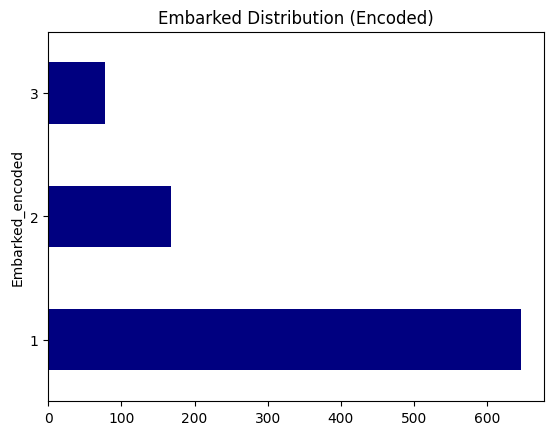

In [85]:
df['Embarked_encoded'].value_counts().sort_index().plot(kind='barh', color='navy')
plt.title('Embarked Distribution (Encoded)')
plt.show()


#### Question: Display the first 10 raws of your dataset after all applied preprocessing steps. Remember: 

In [ ]:
columns = ['Survived','Pclass', 'Sex_encoded', 'Ticket', 'Age_group_encoded', 'FamilyGroup_encoded', 'Embarked_encoded', 'Fare_zscore']
print(df[columns].head(10))


   Survived  Pclass  Sex_encoded            Ticket  Age_group_encoded  \
0         0       3            1         A/5 21171                  3   
1         1       1            0          PC 17599                  4   
2         1       3            0  STON/O2. 3101282                  3   
3         1       1            0            113803                  3   
4         0       3            1            373450                  3   
5         0       3            1            330877                  3   
6         0       1            1             17463                  4   
7         0       3            1            349909                  1   
8         1       3            0            347742                  3   
9         1       2            0            237736                  2   

   FamilyGroup_encoded  Embarked_encoded  Fare_zscore  
0                    2                 1    -0.502445  
1                    2                 2     0.786845  
2                    1      

In [87]:
columns_corr = ['Survived', 'Pclass', 'Sex_encoded', 'Age_group_encoded', 'FamilyGroup_encoded', 'Embarked_encoded', 'Fare_zscore']


In [88]:
corr_matrix = df[columns_corr].corr()
print(corr_matrix)


                     Survived    Pclass  Sex_encoded  Age_group_encoded  \
Survived             1.000000 -0.338481    -0.543351          -0.096476   
Pclass              -0.338481  1.000000     0.131900          -0.324774   
Sex_encoded         -0.543351  0.131900     1.000000           0.109425   
Age_group_encoded   -0.096476 -0.324774     0.109425           1.000000   
FamilyGroup_encoded  0.134197 -0.054495    -0.289929          -0.307222   
Embarked_encoded     0.106811  0.045702    -0.116569          -0.013724   
Fare_zscore          0.257307 -0.549500    -0.182333           0.083321   

                     FamilyGroup_encoded  Embarked_encoded  Fare_zscore  
Survived                        0.134197          0.106811     0.257307  
Pclass                         -0.054495          0.045702    -0.549500  
Sex_encoded                    -0.289929         -0.116569    -0.182333  
Age_group_encoded              -0.307222         -0.013724     0.083321  
FamilyGroup_encoded          

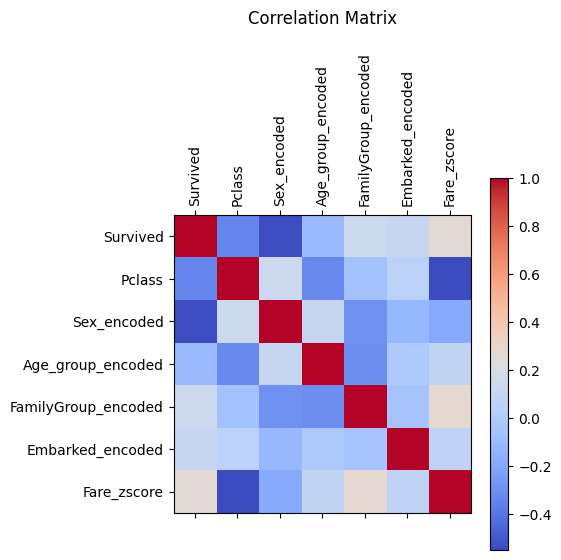

In [89]:
cax = plt.matshow(corr_matrix, cmap='coolwarm')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.colorbar(cax)
plt.title('Correlation Matrix', pad=20)
plt.show()


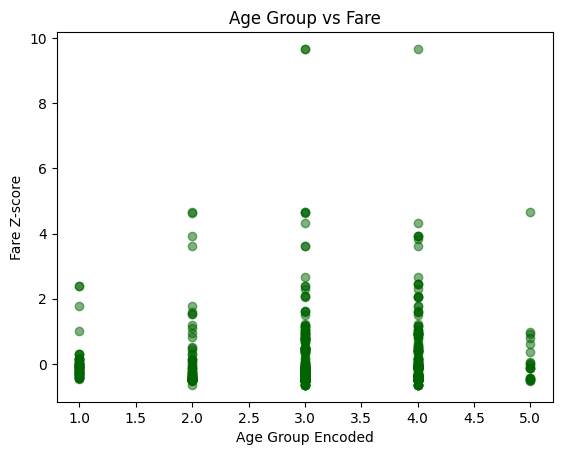

In [90]:
plt.scatter(df['Age_group_encoded'], df['Fare_zscore'], alpha=0.5, color='darkgreen')
plt.xlabel('Age Group Encoded')
plt.ylabel('Fare Z-score')
plt.title('Age Group vs Fare')
plt.show()


Outlier Removal

In [91]:
outliers = df[np.abs(df['Fare_zscore']) > 3]
print('Number of outliers:', len(outliers))
print(outliers[['Fare', 'Fare_zscore']].head())


Number of outliers: 20
         Fare  Fare_zscore
27   263.0000     4.647001
88   263.0000     4.647001
118  247.5208     4.335332
258  512.3292     9.667167
299  247.5208     4.335332


In [92]:
df_clean = df[np.abs(df['Fare_zscore']) <= 3]
print(f'Original shape: {df.shape}')
print(f'Clean shape: {df_clean.shape}')


Original shape: (891, 19)
Clean shape: (871, 19)


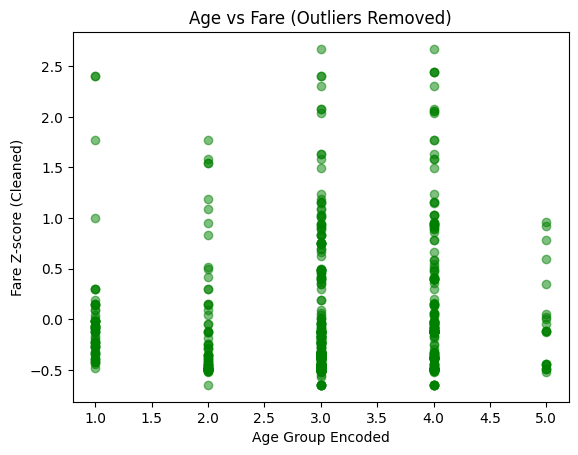

In [93]:
plt.scatter(df_clean['Age_group_encoded'], df_clean['Fare_zscore'], alpha=0.5, color='green')
plt.xlabel('Age Group Encoded')
plt.ylabel('Fare Z-score (Cleaned)')
plt.title('Age vs Fare (Outliers Removed)')
plt.show()
